In [2]:
!pip install timm -q
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

In [3]:
DATA_DIR = "/kaggle/input/datasets/resvit/venkat/Final_Data"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [5]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

inception = timm.create_model('inception_v3', pretrained=True, num_classes=4)
inception = inception.to(device)

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

In [7]:
# 🔥 Boost weak classes (important)
weights = torch.tensor([1.0, 1.0, 1.3, 1.3]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(inception.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [8]:
def train_inception(epochs=15):

    best_f1 = 0

    for epoch in range(epochs):

        # ========================
        # 🔹 TRAIN
        # ========================
        inception.train()
        total_loss = 0

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            # 🔥 Resize to 299 for Inception
            images_299 = torch.nn.functional.interpolate(images, size=(299,299))

            optimizer.zero_grad()

            outputs = inception(images_299)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

        # ========================
        # 🔹 VALIDATION
        # ========================
        inception.eval()
        preds_all, labels_all = [], []

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                images_299 = torch.nn.functional.interpolate(images, size=(299,299))

                outputs = inception(images_299)
                preds = torch.argmax(outputs, dim=1)

                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

        val_f1 = f1_score(labels_all, preds_all, average='macro')

        print(f"Epoch {epoch+1}")
        print(f"Loss: {total_loss:.4f}")
        print(f"Val F1: {val_f1:.4f}")

        # 🔥 SAVE BEST MODEL
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(inception.state_dict(), "best_inception.pth")
            print("✅ Saved best_inception.pth")

        print(f"Best F1: {best_f1:.4f}")
        print("-"*40)

    print("🔥 Training Done")

In [9]:
train_inception(epochs=30)

Epoch 1
Loss: 258.3503
Val F1: 0.7958
✅ Saved best_inception.pth
Best F1: 0.7958
----------------------------------------
Epoch 2
Loss: 199.1755
Val F1: 0.8822
✅ Saved best_inception.pth
Best F1: 0.8822
----------------------------------------
Epoch 3
Loss: 169.5310
Val F1: 0.8833
✅ Saved best_inception.pth
Best F1: 0.8833
----------------------------------------
Epoch 4
Loss: 151.7604
Val F1: 0.8839
✅ Saved best_inception.pth
Best F1: 0.8839
----------------------------------------
Epoch 5
Loss: 126.6473
Val F1: 0.8952
✅ Saved best_inception.pth
Best F1: 0.8952
----------------------------------------
Epoch 6
Loss: 110.0514
Val F1: 0.8484
Best F1: 0.8952
----------------------------------------
Epoch 7
Loss: 87.9772
Val F1: 0.9121
✅ Saved best_inception.pth
Best F1: 0.9121
----------------------------------------
Epoch 8
Loss: 57.0455
Val F1: 0.9180
✅ Saved best_inception.pth
Best F1: 0.9180
----------------------------------------
Epoch 9
Loss: 39.6883
Val F1: 0.9318
✅ Saved best_inc

In [10]:
import os
print("Saved:", os.path.exists("best_inception.pth"))

Saved: True


In [17]:
!pip install timm -q

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.metrics import f1_score, classification_report

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 16
IMG_SIZE = 224

DATA_DIR = "/kaggle/input/datasets/resvit/venkat/Final_Data"

In [20]:
train_transform = transforms.Compose([
    transforms.Resize((380,380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((380,380)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

import numpy as np
from torch.utils.data import WeightedRandomSampler

targets = [label for _, label in train_dataset]

class_counts = np.bincount(targets)
class_weights = 1. / class_counts

sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

class_names = train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_names = train_dataset.classes

In [22]:
targets = [label for _, label in train_dataset]

class_counts = np.bincount(targets)
class_weights = 1. / class_counts

sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [23]:
model = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=4)
model = model.to(device)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [24]:
weights = torch.tensor([1.0, 1.0, 1.3, 1.3]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [25]:
def train_effnet(epochs=30):

    best_f1 = 0

    for epoch in range(epochs):

        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        scheduler.step()

        # VALIDATION
        model.eval()
        preds_all, labels_all = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

        val_f1 = f1_score(labels_all, preds_all, average='macro')

        print(f"Epoch {epoch+1} | F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model.pth")
            print("✅ Saved best_model.pth")

    print("🔥 EfficientNet Training Done")

In [26]:
train_effnet(epochs=30)

Epoch 1 | F1: 0.8053
✅ Saved best_model.pth
Epoch 2 | F1: 0.8538
✅ Saved best_model.pth
Epoch 3 | F1: 0.8404
Epoch 4 | F1: 0.8413
Epoch 5 | F1: 0.7746
Epoch 6 | F1: 0.8707
✅ Saved best_model.pth
Epoch 7 | F1: 0.8597
Epoch 8 | F1: 0.8947
✅ Saved best_model.pth
Epoch 9 | F1: 0.8953
✅ Saved best_model.pth
Epoch 10 | F1: 0.8831
Epoch 11 | F1: 0.9017
✅ Saved best_model.pth
Epoch 12 | F1: 0.8932
Epoch 13 | F1: 0.9146
✅ Saved best_model.pth
Epoch 14 | F1: 0.9049
Epoch 15 | F1: 0.9085
Epoch 16 | F1: 0.9044
Epoch 17 | F1: 0.8875
Epoch 18 | F1: 0.8983
Epoch 19 | F1: 0.8253
Epoch 20 | F1: 0.9048
Epoch 21 | F1: 0.8699
Epoch 22 | F1: 0.9094
Epoch 23 | F1: 0.9082
Epoch 24 | F1: 0.8918
Epoch 25 | F1: 0.9112
Epoch 26 | F1: 0.9132
Epoch 27 | F1: 0.9186
✅ Saved best_model.pth
Epoch 28 | F1: 0.9357
✅ Saved best_model.pth
Epoch 29 | F1: 0.9192
Epoch 30 | F1: 0.9221
🔥 EfficientNet Training Done


In [28]:
import os
print("Saved:", os.path.exists("best_model.pth"))

Saved: True


In [29]:
model1 = timm.create_model('tf_efficientnet_b4', pretrained=False, num_classes=4)
model2 = timm.create_model('inception_v3', pretrained=False, num_classes=4)

model1.load_state_dict(torch.load("best_model.pth", map_location=device))
model2.load_state_dict(torch.load("best_inception.pth", map_location=device))

model1.to(device).eval()
model2.to(device).eval()

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [30]:
def ensemble_predict(images):

    # Resize for Inception
    images_299 = torch.nn.functional.interpolate(images, size=(299,299))

    out1 = torch.softmax(model1(images), dim=1)      # EffNet
    out2 = torch.softmax(model2(images_299), dim=1)  # Inception

    # 🔥 CLASS-AWARE WEIGHTING (IMPORTANT)
    # Focus more on bacterial & viral
    weights = torch.tensor([1.0, 1.0, 1.3, 1.3]).to(device)

    out = (0.5*out1 + 0.5*out2) * weights

    return out

In [31]:
def tta(images):

    outputs = []

    transforms_list = [
        lambda x: x,
        lambda x: torch.flip(x, dims=[-1]),  # horizontal flip
        lambda x: torch.flip(x, dims=[-2]),  # vertical flip
    ]

    for transform in transforms_list:
        aug = transform(images)
        out = ensemble_predict(aug)
        outputs.append(out)

    return torch.mean(torch.stack(outputs), dim=0)

In [34]:
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [38]:
from sklearn.metrics import f1_score
import torch

def train_model(epochs=30):

    # ✅ FIXED SCALER
    scaler = torch.cuda.amp.GradScaler()
    best_f1 = 0

    for epoch in range(epochs):

        # ========================
        # 🔹 TRAIN
        # ========================
        model.train()
        total_loss = 0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # ✅ FIXED AUTOCAST
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()

            # 🔥 GRADIENT CLIPPING (IMPORTANT)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

            scaler.step(optimizer)
            scaler.update()

            # 🔥 PROPER LOSS TRACKING
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

        train_loss = total_loss / total_samples

        # ========================
        # 🔹 VALIDATION
        # ========================
        model.eval()
        preds_all, labels_all = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

        val_f1 = f1_score(labels_all, preds_all, average='macro')

        # ========================
        # 🔹 SCHEDULER
        # ========================
        scheduler.step()

        # ========================
        # 🔹 SAVE BEST MODEL
        # ========================
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model.pth")

        # ========================
        # 🔹 LOGS
        # ========================
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    print("✅ Training Complete")

In [39]:
train_model(epochs=30)

/tmp/ipykernel_55/4017685836.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/4017685836.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/30]
Train Loss: 0.2095
Val F1: 0.8613
Best F1: 0.8613
--------------------------------------------------


/tmp/ipykernel_55/4017685836.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [2/30]
Train Loss: 0.2458
Val F1: 0.9200
Best F1: 0.9200
--------------------------------------------------


/tmp/ipykernel_55/4017685836.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch [28/30]
Train Loss: 0.0259
Val F1: 0.9399
Best F1: 0.9457
--------------------------------------------------


/tmp/ipykernel_55/4017685836.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [29/30]
Train Loss: 0.0178
Val F1: 0.9483
Best F1: 0.9483
--------------------------------------------------


/tmp/ipykernel_55/4017685836.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [30/30]
Train Loss: 0.0202
Val F1: 0.9457
Best F1: 0.9483
--------------------------------------------------
✅ Training Complete


In [40]:
from sklearn.metrics import f1_score, classification_report

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = tta(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("🔥 FINAL BOOSTED F1:", f1_score(all_labels, all_preds, average='macro'))
print(classification_report(all_labels, all_preds, target_names=class_names))

🔥 FINAL BOOSTED F1: 0.9344150195185863
                     precision    recall  f1-score   support

           Covid-19       0.99      1.00      1.00       405
             Normal       0.99      0.98      0.98       405
Pneumonia-Bacterial       0.84      0.94      0.89       405
    Pneumonia-Viral       0.92      0.83      0.87       405

           accuracy                           0.93      1620
          macro avg       0.94      0.93      0.93      1620
       weighted avg       0.94      0.93      0.93      1620



In [41]:
import torch
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = timm.create_model('tf_efficientnet_b4', pretrained=False, num_classes=4)
model2 = timm.create_model('inception_v3', pretrained=False, num_classes=4)

# ✅ SAFE LOAD
import os

if os.path.exists("best_model.pth"):
    model1.load_state_dict(torch.load("best_model.pth", map_location=device))
else:
    print("⚠️ best_model.pth not found")

if os.path.exists("best_inception.pth"):
    model2.load_state_dict(torch.load("best_inception.pth", map_location=device))
else:
    print("⚠️ best_inception.pth not found")

model1.to(device).eval()
model2.to(device).eval()

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [42]:
import torch.nn.functional as F

def ensemble_predict(images):

    # 🔥 Resize properly
    img224 = F.interpolate(images, size=(224,224), mode='bilinear')
    img299 = F.interpolate(images, size=(299,299), mode='bilinear')

    # 🔥 Predictions
    out1 = torch.softmax(model1(img224), dim=1)   # EfficientNet
    out2 = torch.softmax(model2(img299), dim=1)   # Inception

    # 🔥 CLASS-AWARE WEIGHTING (VERY IMPORTANT)
    weights = torch.tensor([1.0, 1.0, 1.2, 1.2]).to(device)

    # 🔥 Ensemble weights (tuned)
    out = (0.55 * out1 + 0.45 * out2) * weights

    return out

In [43]:
def tta(images):

    outs = []

    for transform in [
        lambda x: x,
        lambda x: torch.flip(x, dims=[3]),  # horizontal
        lambda x: torch.flip(x, dims=[2]),  # vertical
    ]:
        aug = transform(images)
        outs.append(ensemble_predict(aug))

    return torch.mean(torch.stack(outs), dim=0)

In [44]:
from sklearn.metrics import f1_score, classification_report

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = tta(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("🔥 FINAL F1:", f1_score(all_labels, all_preds, average='macro'))
print(classification_report(all_labels, all_preds, target_names=class_names))

🔥 FINAL F1: 0.949566108295611
                     precision    recall  f1-score   support

           Covid-19       0.99      1.00      0.99       405
             Normal       0.99      0.96      0.98       405
Pneumonia-Bacterial       0.93      0.90      0.91       405
    Pneumonia-Viral       0.89      0.94      0.91       405

           accuracy                           0.95      1620
          macro avg       0.95      0.95      0.95      1620
       weighted avg       0.95      0.95      0.95      1620



In [52]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 77.4 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=428425cc3935c19ee549a0f5c6c3d11f36841f0a53bb57843f71a0a5ab9064b5
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [53]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2

In [55]:
# EfficientNet last conv layer
target_layers = [model1.conv_head]   # for EfficientNet-B4

# If error:
# target_layers = [model1.blocks[-1]]

In [56]:
def generate_gradcam(image_tensor):

    cam = GradCAM(model=model1, target_layers=target_layers)

    input_tensor = F.interpolate(image_tensor, size=(224,224))

    targets = None  # predicted class

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    # Convert image
    img = input_tensor[0].cpu().permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    return visualization

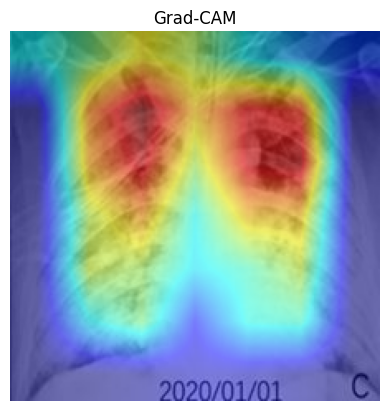

In [57]:
import matplotlib.pyplot as plt

for images, labels in test_loader:
    images = images.to(device)

    cam_img = generate_gradcam(images)

    plt.imshow(cam_img)
    plt.title("Grad-CAM")
    plt.axis('off')
    break

In [60]:
def generate_masks(N=1000, s=8, p1=0.5):
    masks = []
    for _ in range(N):
        mask = np.random.choice([0,1], size=(s,s), p=[1-p1, p1])
        mask = cv2.resize(mask.astype(np.float32), (224,224))
        masks.append(mask)
    return np.array(masks)

In [61]:
def rise_explain(image):

    model1.eval()

    img = F.interpolate(image, size=(224,224))
    masks = generate_masks(500)

    preds = []
    for mask in masks:
        mask_tensor = torch.tensor(mask).unsqueeze(0).unsqueeze(0).to(device)
        masked_img = img * mask_tensor

        out = torch.softmax(model1(masked_img), dim=1)
        preds.append(out.detach().cpu().numpy())

    preds = np.array(preds)
    saliency = np.mean(masks * preds[:,0,0][:,None,None], axis=0)

    return saliency

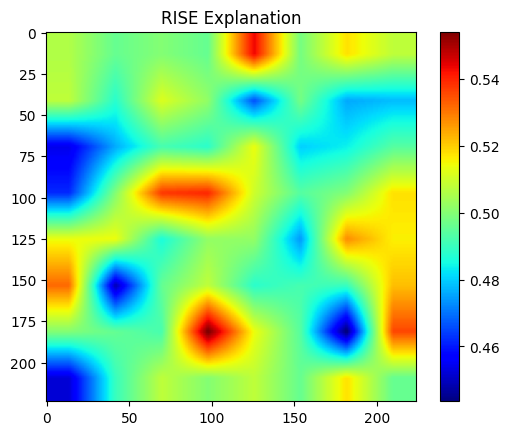

In [62]:
for images, _ in test_loader:
    images = images.to(device)

    saliency = rise_explain(images)

    plt.imshow(saliency, cmap='jet')
    plt.title("RISE Explanation")
    plt.colorbar()
    break

In [63]:
def visualize_features(model, image):

    features = []

    def hook_fn(module, input, output):
        features.append(output)

    handle = model1.conv_head.register_forward_hook(hook_fn)

    _ = model1(F.interpolate(image, (224,224)))

    handle.remove()

    feat_map = features[0][0].cpu()

    # show first 6 feature maps
    plt.figure(figsize=(10,5))
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(feat_map[i].detach().numpy(), cmap='viridis')
        plt.axis('off')
    plt.suptitle("Feature Maps")
    plt.show()

In [64]:
def visualize_ensemble_attention(images):

    img224 = F.interpolate(images, (224,224))
    img299 = F.interpolate(images, (299,299))

    out1 = torch.softmax(model1(img224), dim=1)
    out2 = torch.softmax(model2(img299), dim=1)

    print("EfficientNet Confidence:", out1)
    print("Inception Confidence:", out2)

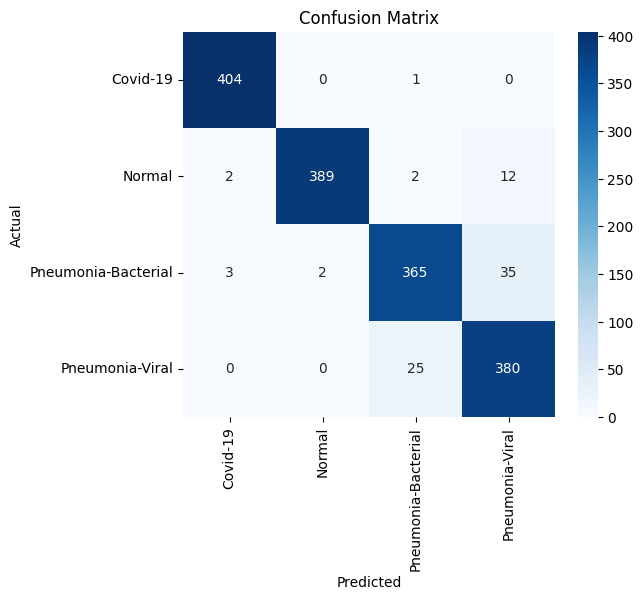

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()